# Medida de Afinidade

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
sns.set_theme()
from pprint import pprint

In [2]:
# Para melhorar a visualização das tabelas
pd.options.display.float_format = '{:.2f}'.format

In [3]:
import sys
import importlib

# Salve o caminho original
original_path = sys.path.copy()

# Adicione o novo caminho


sys.path.insert(0, '../config/')

# Importe o módulo
import plot_functions

importlib.reload(plot_functions)

# Restaure o caminho original
sys.path = original_path


In [4]:
open_path = os.path.join('..', 'dataset', 'ativos_filtrados_mapeados.parquet')

df_leads = pd.read_parquet(open_path,engine='pyarrow')[['cnpj_basico','razao_social','uf','porte_empresa','cnae_fiscal_principal','identificador_matriz_filial']]

In [5]:
open_path = os.path.join('..', 'dataset', 'medidas_proxy.csv')

df_scores = pd.read_csv(open_path, engine='python', sep=',')

In [6]:
# Mapeamento dos estados para nome por extenso
mapping = {'uf':{
    'AC': 'Acre',
    'AL': 'Alagoas',
    'AP': 'Amapá',
    'AM': 'Amazonas',
    'BA': 'Bahia',
    'CE': 'Ceará',
    'DF': 'Distrito Federal',
    'ES': 'Espírito Santo',
    'GO': 'Goiás',
    'MA': 'Maranhão',
    'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul',
    'MG': 'Minas Gerais',
    'PA': 'Pará',
    'PB': 'Paraíba',
    'PR': 'Paraná',
    'PE': 'Pernambuco',
    'PI': 'Piauí',
    'RJ': 'Rio de Janeiro',
    'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul',
    'RO': 'Rondônia',
    'RR': 'Roraima',
    'SC': 'Santa Catarina',
    'SP': 'São Paulo',
    'SE': 'Sergipe',
    'TO': 'Tocantins',
    'EX': 'Estrangeiro'}}

In [7]:
df_leads = df_leads.replace(mapping)

In [8]:
df_leads = df_leads.rename(columns={
    'razao_social':'Razão Social',
    'uf':'Unidade Federal',
    'porte_empresa':'Porte da Empresa',
    'cnae_fiscal_principal':'CNAE',
    'identificador_matriz_filial':'Matriz-Filial'})

In [9]:
df_leads.head(4)

,cnpj_basico,Razão Social,Unidade Federal,Porte da Empresa,CNAE,Matriz-Filial
0,7756651,BRASIL TECPAR SERVICOS DE TELECOMUNICACOES S.A,Mato Grosso do Sul,Demais,Provedores de redes,Filial
1,7756651,BRASIL TECPAR SERVICOS DE TELECOMUNICACOES S.A,Mato Grosso,Demais,Provedores de redes,Filial
2,4679549,MERANO GASTRONOMIA BORGUEZAM LTDA,Paraná,Micro empresa,Escritório e apoio administrativo,Matriz
3,4718504,RBM RAMIRES LOCADORA LTDA,São Paulo,Demais,Locação de automóveis sem condutor,Matriz


In [10]:
df_scores

,Atributo,Premium,Long Tail
0,Unidade Federal,0,0
1,Porte da Empresa,10,10
2,Matriz-Filial,5,5
3,CNAE,10,10
4,Acre,1,1
5,Alagoas,3,3
6,Amapá,1,1
7,Amazonas,1,1
8,Bahia,3,3
9,Ceará,3,3


## Métrica de Score

É sabido, pela área de negócios, a Telit Cinterion separa clientes em duas categorias: Premium e Long Tail. Essa separação favorece uma alocação de recursos de marketing mais eficiente. Tendo em vista essa distinção, optou-se por calcular um nível de afinidade com o que seria um "cliente em potencial ideal".

Um de nossos integrantes assumiu o papel de stakeholder e nos forneceu, via [Google Forms](https://forms.gle/3xPr2n3BKjNHaKVz7), valores de ranking para cada uma das quatro variáveis categóricas independentes e suas respectivas categorias, numa escala de 0% (irrelevante) a 100% (imprescindível), informando o quanto determinado atributo é relevante ao se considerar abordar um novo possível cliente Premium ou Long Tail.

Em posse desses valores, sendo ***V*** o score de certa variável e ***C*** o score de certa categoria que compõe a variável ***V***, foi desenvolvida a seguinte equação:

$$S_v=0.5+V(C_v-0.5)$$

Esta equação faz com que variáveis irrelevantes ($V=0$) tenham score $0.5$ para qualquer valor de $C_v$.  
Para variáveis imprescindíveis ($V=1$), o score depende inteiramente da pontuação dada à categoria ($S_v=C_v$).  
Quaisquer valores para $V$ entre 0 e 1 controlam o efeito de $C_v$ como resultado de $S_v$.

O score final de um exemplar para Premium e para Long Tail será a média dos scores das quatro variáveis.

Optou-se por essa abordagem para que a natureza da variável controlasse o impacto de suas categorias, sem que a irrelevância fosse atribuda aos exemplares, mas à quantidade de informação fornecida pelos atributos. Ou seja, variáveis com menor relevância tendem a aproximar o score de todas as empresas ao nível de 50%.

**Exemplo**:  
1. Suponha que a empresa XYZ tem as seguintes características:
  * $Unidade Federal=SP$
  * $Porte=Demais$
  * $Identificador=Filial$
  * $CNAE=Provedores De Redes$  
  
2. e que os scores **Long Tail** atribuidos a essas catedorias e suas variáveis sejam:
  * $Unidade Federal=0.2$
  * $Porte=0.8$
  * $Identificador=0.4$
  * $CNAE=1.0$
  * $SP=0.6$
  * $Demais=1.0$
  * $Filial=0.4$
  * $Provedores De Redes=0.6$  
  
3. Estes seriam os valores de score de cada variável para a empresa XYZ:
  * $S_{UnidadeFederal}=0.5+UnidadeFederal(SP-0.5)$  
$S_{UnidadeFederal}=0.5+0.2(0.6-0.5)$  
$S_{UnidadeFederal}=0.52$
  
  * $S_{Porte}=0.5+Porte(Demais-0.5)$  
$S_{Porte}=0.5+0.8(1.0-0.5)$  
$S_{Porte}=0.9$
  
  * $S_{Identificador}=0.5+Identificador(Filial-0.5)$  
$S_{Identificador}=0.5+0.4(0.4-0.5)$  
$S_{Identificador}=0.46$
  
  * $S_{CNAE}=0.5+CNAE(Provedores De Redes-0.5)$  
$S_{CNAE}=0.5+1.0(0.6-0.5)$  
$S_{CNAE}=0.6$  
  
4. O score Long Tail para a empresa é a média das quatro medidas:
  * $S_{Long Tail}=\frac{\sum{V_{LongTail}}}{4}=\frac{0.52+0.9+0.46+0.6}{4}=0.62$  
  
5. Aplicando a normalização pelo máximo, supondo que o maior valor de score Long Tail seja $0.77$:
  * $Snorm_{Long Tail}=\frac{0.62}{0.77}*100\%=82,52\%$

O cálculo é o mesmo para $Snorm_{Premium}$, apenas substituindo os scores atribuídos às variáveis e às categorias.

## Estrutura

* Criar duas colunas: uma de Score Premium e outra de Score LongTail
* Cada score geral é a soma de quatro scores de variáveis;
* Cada score de variável é baseado numa variável e sua categoria, conforme a equação abaixo.

In [11]:
variáveis = ('Unidade Federal','Porte da Empresa','Matriz-Filial','CNAE')

In [12]:
# Busca os valores das pontuações para clientes Premium e Long Tail para variáveis e para categorias

for col in variáveis:
    df_leads['score_Premium_var_'+col] = df_scores.loc[df_scores['Atributo'] == col, 'Premium'].values[0]/10
    df_leads['score_Premium_cat_'+col] = df_leads[col].map(df_scores.set_index('Atributo')['Premium'])/10
    df_leads['score_LongTail_var_'+col] = df_scores.loc[df_scores['Atributo'] == col, 'Long Tail'].values[0]/10
    df_leads['score_LongTail_cat_'+col] = df_leads[col].map(df_scores.set_index('Atributo')['Long Tail'])/10

In [13]:
df_leads[df_leads.isna().any(axis=1)]

,cnpj_basico,Razão Social,Unidade Federal,Porte da Empresa,CNAE,Matriz-Filial,score_Premium_var_Unidade Federal,score_Premium_cat_Unidade Federal,score_LongTail_var_Unidade Federal,score_LongTail_cat_Unidade Federal,...,score_LongTail_var_Porte da Empresa,score_LongTail_cat_Porte da Empresa,score_Premium_var_Matriz-Filial,score_Premium_cat_Matriz-Filial,score_LongTail_var_Matriz-Filial,score_LongTail_cat_Matriz-Filial,score_Premium_var_CNAE,score_Premium_cat_CNAE,score_LongTail_var_CNAE,score_LongTail_cat_CNAE
861,30813294,TELEFONICA INTERNATIONAL WHOLESALE SERVICES II...,Estrangeiro,None,Provedores de redes,Matriz,0.00,0.80,0.00,0.80,...,1.00,NaN,0.50,0.00,0.50,0.00,1.00,0.00,1.00,0.00
20664,37807777,FREEBALANCE INC.,Estrangeiro,None,Programas de computador customizáveis,Matriz,0.00,0.80,0.00,0.80,...,1.00,NaN,0.50,0.00,0.50,0.00,1.00,0.50,1.00,0.50
21388,48836732,PROTEGE SAGI S.L.,Estrangeiro,None,Holdings financeiras,Matriz,0.00,0.80,0.00,0.80,...,1.00,NaN,0.50,0.00,0.50,0.00,1.00,0.00,1.00,0.00
24560,48881545,REISDORFER ENGINEERING GMBH,Estrangeiro,None,Instalação e manutenção elétrica,Matriz,0.00,0.80,0.00,0.80,...,1.00,NaN,0.50,0.00,0.50,0.00,1.00,0.00,1.00,0.00
30827,45747542,FAF INVESTMENTS HOLDING TD,Estrangeiro,None,Escritório e apoio administrativo,Matriz,0.00,0.80,0.00,0.80,...,1.00,NaN,0.50,0.00,0.50,0.00,1.00,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1662592,44028874,GRUPO HISPATEC INFORMATICA EMPRESARIAL S.A.,Estrangeiro,None,Serviços em tecnologia da informação,Matriz,0.00,0.80,0.00,0.80,...,1.00,NaN,0.50,0.00,0.50,0.00,1.00,0.50,1.00,0.00
1664927,28470004,SACY TECHNOLOGY LLC,Estrangeiro,None,Varejista de telefonia e comunicação,Matriz,0.00,0.80,0.00,0.80,...,1.00,NaN,0.50,0.00,0.50,0.00,1.00,0.00,1.00,0.00
1667870,25232682,DELPHIX CORP.,Estrangeiro,None,Serviços em tecnologia da informação,Matriz,0.00,0.80,0.00,0.80,...,1.00,NaN,0.50,0.00,0.50,0.00,1.00,0.50,1.00,0.00
1677376,20592152,"TRISON ACUSTICA, SOCIEDAD LIMITADA",Estrangeiro,None,Instalação e manutenção elétrica,Matriz,0.00,0.80,0.00,0.80,...,1.00,NaN,0.50,0.00,0.50,0.00,1.00,0.00,1.00,0.00


In [14]:
nan_counts = df_leads.isna().sum()
print("Contagem de NaN por coluna:")
print(nan_counts)

Contagem de NaN por coluna:
cnpj_basico                              0
Razão Social                             0
Unidade Federal                          0
Porte da Empresa                       644
CNAE                                     0
Matriz-Filial                            0
score_Premium_var_Unidade Federal        0
score_Premium_cat_Unidade Federal        0
score_LongTail_var_Unidade Federal       0
score_LongTail_cat_Unidade Federal       0
score_Premium_var_Porte da Empresa       0
score_Premium_cat_Porte da Empresa     644
score_LongTail_var_Porte da Empresa      0
score_LongTail_cat_Porte da Empresa    644
score_Premium_var_Matriz-Filial          0
score_Premium_cat_Matriz-Filial          0
score_LongTail_var_Matriz-Filial         0
score_LongTail_cat_Matriz-Filial         0
score_Premium_var_CNAE                   0
score_Premium_cat_CNAE                   0
score_LongTail_var_CNAE                  0
score_LongTail_cat_CNAE                  0
dtype: int64


In [15]:
# Os valores NaN encontrados correspondem a empresas cujo porte não é informado.
# Para esses valores, será atribuída uma nota média.

df_leads['score_LongTail_cat_Porte da Empresa'] = df_leads['score_LongTail_cat_Porte da Empresa'].fillna(df_leads['score_LongTail_cat_Porte da Empresa'].mean())
df_leads['score_Premium_cat_Porte da Empresa'] = df_leads['score_Premium_cat_Porte da Empresa'].fillna(df_leads['score_Premium_cat_Porte da Empresa'].mean())

In [16]:
nan_counts = df_leads.isna().sum()
print("Contagem de NaN por coluna:")
print(nan_counts)

Contagem de NaN por coluna:
cnpj_basico                              0
Razão Social                             0
Unidade Federal                          0
Porte da Empresa                       644
CNAE                                     0
Matriz-Filial                            0
score_Premium_var_Unidade Federal        0
score_Premium_cat_Unidade Federal        0
score_LongTail_var_Unidade Federal       0
score_LongTail_cat_Unidade Federal       0
score_Premium_var_Porte da Empresa       0
score_Premium_cat_Porte da Empresa       0
score_LongTail_var_Porte da Empresa      0
score_LongTail_cat_Porte da Empresa      0
score_Premium_var_Matriz-Filial          0
score_Premium_cat_Matriz-Filial          0
score_LongTail_var_Matriz-Filial         0
score_LongTail_cat_Matriz-Filial         0
score_Premium_var_CNAE                   0
score_Premium_cat_CNAE                   0
score_LongTail_var_CNAE                  0
score_LongTail_cat_CNAE                  0
dtype: int64


## Cálculo do score geral

In [17]:
df_leads['Premium Unidade Federal'] = 0.5+df_leads['score_Premium_var_Unidade Federal']*(df_leads['score_Premium_cat_Unidade Federal'] - 0.5)

df_leads['Premium Porte da Empresa'] = 0.5+df_leads['score_Premium_var_Porte da Empresa']*(df_leads['score_Premium_cat_Porte da Empresa'] - 0.5)

df_leads['Premium CNAE'] = 0.5+df_leads['score_Premium_var_CNAE']*(df_leads['score_Premium_cat_CNAE'] - 0.5)

df_leads['Premium Matriz-Filial'] = 0.5+df_leads['score_Premium_var_Matriz-Filial']*(df_leads['score_Premium_cat_Matriz-Filial'] - 0.5)

df_leads['LongTail Unidade Federal'] = 0.5+df_leads['score_LongTail_var_Unidade Federal']*(df_leads['score_LongTail_cat_Unidade Federal'] - 0.5)

df_leads['LongTail Porte da Empresa'] = 0.5+df_leads['score_LongTail_var_Porte da Empresa']*(df_leads['score_LongTail_cat_Porte da Empresa'] - 0.5)

df_leads['LongTail CNAE'] = 0.5+df_leads['score_LongTail_var_CNAE']*(df_leads['score_LongTail_cat_CNAE'] - 0.5)

df_leads['LongTail Matriz-Filial'] = 0.5+df_leads['score_LongTail_var_Matriz-Filial']*(df_leads['score_LongTail_cat_Matriz-Filial'] - 0.5)

In [18]:
df_leads[[
    'Premium Unidade Federal',
    'Premium Porte da Empresa',
    'Premium CNAE',
    'Premium Matriz-Filial',
    'LongTail Unidade Federal',
    'LongTail Porte da Empresa',
    'LongTail CNAE',
    'LongTail Matriz-Filial']].head(4)

,Premium Unidade Federal,Premium Porte da Empresa,Premium CNAE,Premium Matriz-Filial,LongTail Unidade Federal,LongTail Porte da Empresa,LongTail CNAE,LongTail Matriz-Filial
0,0.50,1.00,0.00,0.25,0.50,0.00,0.00,0.25
1,0.50,1.00,0.00,0.25,0.50,0.00,0.00,0.25
2,0.50,0.00,0.00,0.25,0.50,1.00,0.00,0.25
3,0.50,1.00,1.00,0.25,0.50,0.00,1.00,0.25


In [19]:
df_leads['Score Premium'] = np.mean(df_leads[[
    'Premium Unidade Federal',
    'Premium Porte da Empresa',
    'Premium CNAE',
    'Premium Matriz-Filial']], axis=1)

# max scaling
df_leads['Score Premium'] = df_leads['Score Premium']/df_leads['Score Premium'].max()

In [20]:
df_leads['Score LongTail'] = np.mean(df_leads[[
    'LongTail Unidade Federal',
    'LongTail Porte da Empresa',
    'LongTail CNAE',
    'LongTail Matriz-Filial']], axis=1)

# max scaling
df_leads['Score LongTail'] = df_leads['Score LongTail']/df_leads['Score LongTail'].max()

In [ ]:
df_leads[['cnpj_basico',
          'Razão Social',
          'Score LongTail',
          'LongTail Unidade Federal',
          'LongTail Porte da Empresa',
          'LongTail CNAE',
          'LongTail Matriz-Filial']
          ].sort_values('Score LongTail',ascending=False).drop_duplicates()#[df_leads['Score LongTail'] == 1]

,cnpj_basico,Razão Social,Score LongTail,LongTail Unidade Federal,LongTail Porte da Empresa,LongTail CNAE,LongTail Matriz-Filial
434678,50063815,ACBASTO LOCACOES E SERVICOS LTDA,1.00,0.50,1.00,1.00,0.25
217139,55220314,M.C LOCACAO LTDA,1.00,0.50,1.00,1.00,0.25
217250,56049187,LS LOCACOES LTDA,1.00,0.50,1.00,1.00,0.25
1028990,57833510,57.833.510 DOUGLAS APARECIDO CIRILO DA SILVA,1.00,0.50,1.00,1.00,0.25
631234,50887040,LM ALUGUEL VEICULAR LTDA,1.00,0.50,1.00,1.00,0.25
...,...,...,...,...,...,...,...
921688,17717761,JSELT APOIO ADMINISTRATIVO LTDA,0.27,0.50,0.00,0.00,0.25
921696,17839886,RJG SERVICE CAR CLINICA AUTOMOTIVA LTDA,0.27,0.50,0.00,0.00,0.25
1150597,22788850,GREYCE BERNINI KAPINS FERNANDEZ,0.27,0.50,0.00,0.00,0.25
371271,20854761,YAH TELECOMUNICACOES LTDA.,0.27,0.50,0.00,0.00,0.25


In [34]:
# Exemplos de resultados Premium

df_leads[['Premium Unidade Federal',
          'Premium Porte da Empresa',
          'Premium CNAE',
          'Premium Matriz-Filial',
          'Score Premium']
          ].sample(n=10, weights='Score Premium')

,Premium Unidade Federal,Premium Porte da Empresa,Premium CNAE,Premium Matriz-Filial,Score Premium
4438,0.50,0.00,0.50,0.25,0.45
441729,0.50,0.00,0.00,0.25,0.27
1340193,0.50,0.00,0.00,0.25,0.27
555424,0.50,0.00,0.00,0.25,0.27
225402,0.50,1.00,0.50,0.25,0.82
273212,0.50,0.50,0.50,0.25,0.64
1003462,0.50,0.00,0.50,0.25,0.45
538128,0.50,0.00,0.00,0.25,0.27
795891,0.50,0.00,0.00,0.25,0.27
38732,0.50,0.00,0.00,0.25,0.27


In [38]:
# Exemplos de resultados LongTail

df_leads[['LongTail Unidade Federal',
          'LongTail Porte da Empresa',
          'LongTail CNAE',
          'LongTail Matriz-Filial',
          'Score LongTail']
          ].sample(n=10, weights='Score LongTail')

,LongTail Unidade Federal,LongTail Porte da Empresa,LongTail CNAE,LongTail Matriz-Filial,Score LongTail
1147003,0.50,0.50,0.00,0.25,0.45
177125,0.50,1.00,0.00,0.25,0.64
1431981,0.50,1.00,0.00,0.25,0.64
104456,0.50,1.00,0.00,0.25,0.64
775374,0.50,1.00,0.00,0.25,0.64
369235,0.50,1.00,0.00,0.25,0.64
1166449,0.50,1.00,0.00,0.25,0.64
1427170,0.50,0.50,1.00,0.25,0.82
312362,0.50,1.00,0.00,0.25,0.64
619917,0.50,0.50,1.00,0.25,0.82


## Descrição dos resultatos

In [23]:
# Proporção de notas máximas

print(f'''Percentual de score máximo (100%):
      
  Premium: {len(df_leads[df_leads['Score Premium'] == 1])*100/len(df_leads):.2f}%  ({len(df_leads[df_leads['Score Premium'] == 1])} empresas)
Long Tail: {len(df_leads[df_leads['Score LongTail'] == 1])*100/len(df_leads):.2f}% ({len(df_leads[df_leads['Score LongTail'] == 1])} empresas)
''')

Percentual de score máximo (100%):
      
  Premium: 0.42%  (7015 empresas)
Long Tail: 2.95% (49730 empresas)



<Axes: >

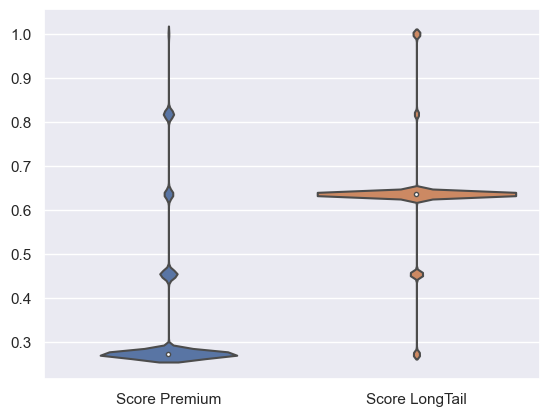

In [24]:
# Gráfico violino: demostrando a distribuição das notas
sns.violinplot(data=df_leads[['Score Premium','Score LongTail']])

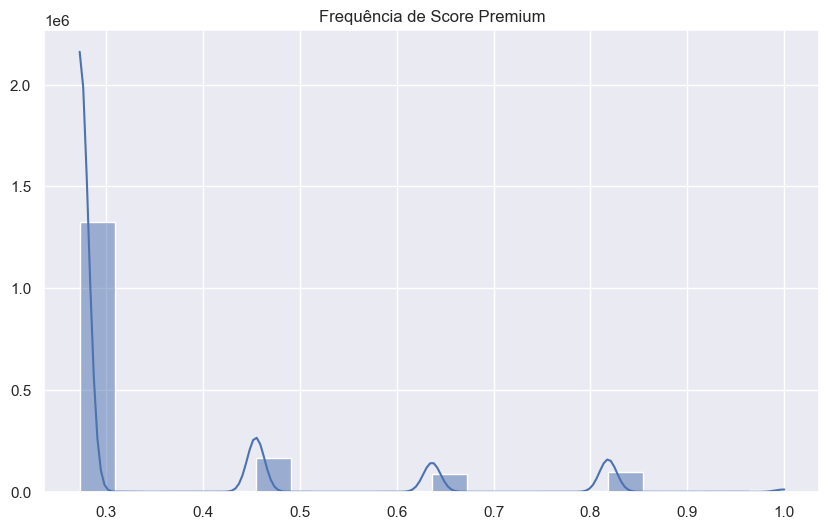

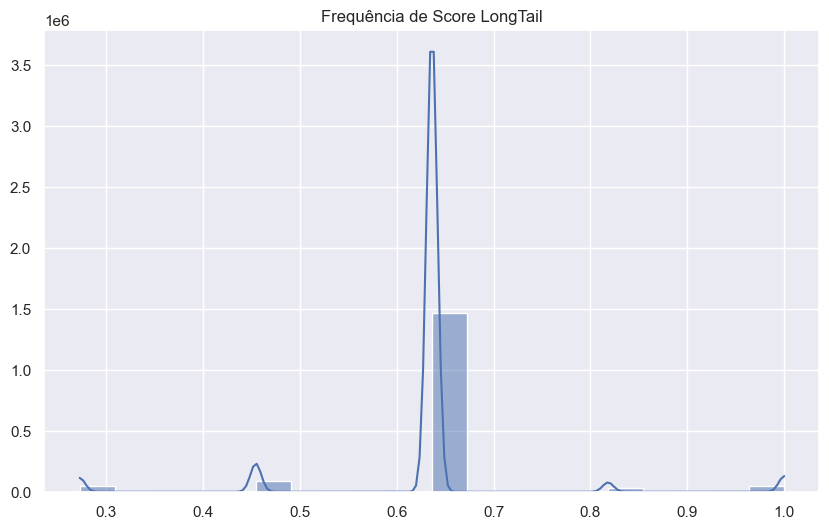

In [25]:
# Histogramas
for col in ['Score Premium','Score LongTail']:
    plot_functions.histograma(df_leads,col,f'Frequência de {col}')

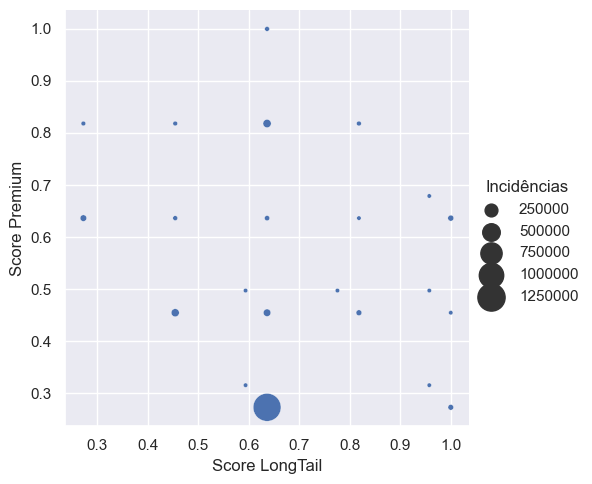

In [26]:
# Contagem das ocorrências de cada par (Score LongTail, Score Premium)
df_inc = (
    df_leads
    .groupby(['Score LongTail', 'Score Premium'])
    .size()
    .reset_index(name='Incidências')
)

sns.relplot(
    data=df_inc,
    x="Score LongTail",
    y="Score Premium",
    size="Incidências",           # Tamanho proporcional ao número de incidências
    sizes=(10, 400),        # Ajuste o range de tamanhos conforme necessário
    kind="scatter"
)

plt.show()


Neste estudo, a métrica de score foi aplicada com o dataframe que carrega unicamente os dados das váriáveis necessárias para tal. Com o conhecimento de quais empresas apresentam maior sucesso de abordagem a priori e com as informações de contato cedidas pela Receita Federal, seria possível contactá-las via telemarketing ou mail-marketing.

Caso fosse possível acessar informações de taxa de conversão e ticket médio dos clientes recorrentes da Telit-Cinterion, seria possível utilizar essas informações juntamente com o número de empresas cujo score é máximo para estimar o faturamente do produto e verificar se seu desenvolvimento é viável.

# Salvando os Dados

Salvando no diretório apropriado sob o nome "score_afinidade.csv"

In [27]:
save_path = os.path.join('..', 'dataset', 'score_afinidade.csv')

df_leads[['cnpj_basico','Razão Social','Score LongTail','Score Premium']].to_csv(save_path, index=False)